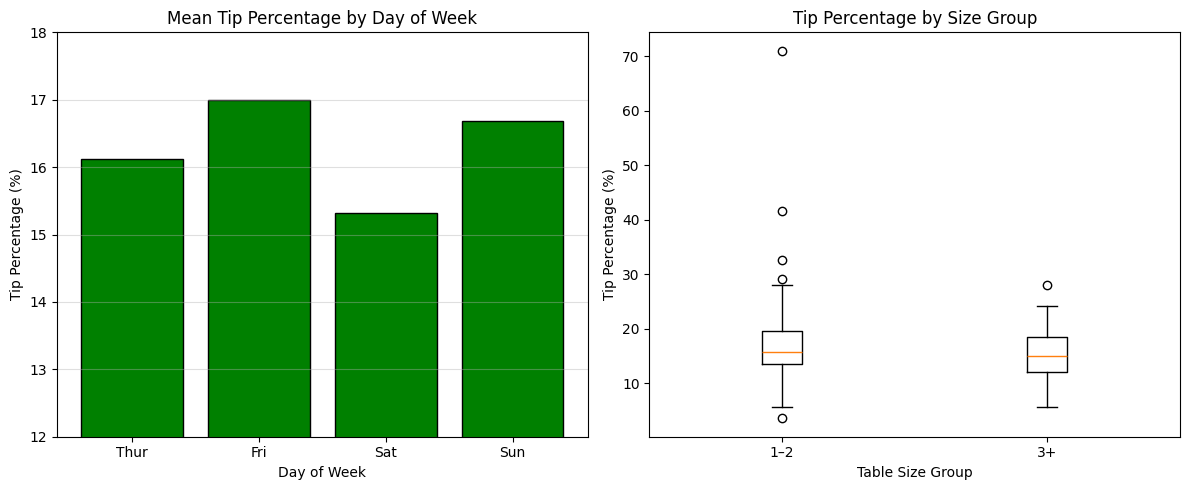

In [5]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load tips dataset ---
df = sns.load_dataset("tips")

# --- Create tip percentage column (as percent, not proportion) ---
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

# --- Compute mean tip percentage by day for the left bar chart ---
mean_by_day = df.groupby("day")["tip_pct"].mean()

# --- Create a "group" column based on party size (1–2 vs 3+) ---
# NOTE: the en-dash below matches your instructions: "1–2"
df["group"] = df["size"].apply(lambda x: "1–2" if x <= 2 else "3+")

# --- Prepare the two Series for the right boxplot (only tip_pct column) ---
group1 = df.loc[df["group"] == "1–2", "tip_pct"]
group2 = df.loc[df["group"] == "3+",  "tip_pct"]

# --- Build side-by-side figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ===== Left: Mean Tip Percentage by Day of Week (green bars, grid, ylim) =====
ax1.bar(mean_by_day.index, mean_by_day.values, color="green", edgecolor="black")
ax1.set_title("Mean Tip Percentage by Day of Week")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Tip Percentage (%)")
ax1.set_ylim(12, 18)               # as required
ax1.grid(True, axis="y", alpha=0.4) # grid on the left chart

# ===== Right: Boxplot by size group (1–2 vs 3+) =====
# Use the two Series as the data source, set tick labels, label axes, and title
ax2.boxplot([group1, group2], tick_labels=["1–2", "3+"])
ax2.set_ylabel("Tip Percentage (%)")
ax2.set_xlabel("Table Size Group")         # required: set_xlabel
ax2.set_title("Tip Percentage by Size Group")  # required: set_title

plt.tight_layout()
plt.show()


In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,group
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,1–2
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3+
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,3+
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,1–2
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,3+
